In [1]:
import dbof.llc4320_ingestion.get_raw_data as get_raw_data

In [23]:
LLC_SURF_SOURCE_V2 = {
    "s3_endpoint": "https://s3-west.nrp-nautilus.io",
    "bucket":      "llc4320-v2/",
    "folder":      "SURFACE",
}

date_string = "2023-07-13 01:00:00"
vars = ["Theta"]
LLC_FACES                = range(13)

ds_llc = get_raw_data.get_llc_timestep_data(
                LLC_SURF_SOURCE_V2["s3_endpoint"],
                LLC_SURF_SOURCE_V2["bucket"],
                LLC_SURF_SOURCE_V2["folder"],
                date_string,
                face_range=LLC_FACES,
                vars_requested=vars,
            )

LLC timestep data loaded: 20230713T01.zarr, vars=['Theta']


In [24]:
import xarray as xr

In [25]:
# ds_grid = get_raw_data.get_llc_depth_gridfile(LLC_SURF_SOURCE_V2["s3_endpoint"], LLC_SURF_SOURCE_V2["bucket"], LLC_SURF_SOURCE_V2["folder"], 
#                        "grid.zarr")

s3_url = get_raw_data._build_s3_store_url(LLC_SURF_SOURCE_V2["bucket"], LLC_SURF_SOURCE_V2["folder"], 
                             "grid.zarr")

    # # Grid store chunks: match on-disk layout to avoid rechunk overhead.
    # # 2D vars: (face=13, j=720, i=720).
    # # 3D vars (hFacC/S/W): on-disk k=1 — keep k=1 so isel(k=0) reads
    # # exactly one stored object per spatial tile instead of all 51.
_grid_chunks = {
        "face": 13, "k": 1, "k_l": 1,
        "j": 720, "i": 720
    }

grid = xr.open_zarr(
        s3_url,
        consolidated=False,
        chunks=_grid_chunks,
        storage_options=get_raw_data._llc_depth_storage_options(LLC_SURF_SOURCE_V2["s3_endpoint"]),
)

/tmp/ipykernel_367/667853591.py:16: UserWarning: The specified chunks separate the stored chunks along dimension "k" starting at index 1. This could degrade performance. Instead, consider rechunking after loading.
  grid = xr.open_zarr(


In [26]:
grid.XC

<xarray.DataArray 'XC' (face: 13, j: 4320, i: 4320)> Size: 970MB
dask.array<open_dataset-XC, shape=(13, 4320, 4320), dtype=float32, chunksize=(13, 720, 720), chunktype=numpy.ndarray>
Coordinates:
  * face     (face) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int64 35kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
  * i        (i) int64 35kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
Attributes:
    long_name:    longitude of cell centre
    units:        degrees_east
    source_file:  XC.data

In [27]:
ds_llc

<xarray.Dataset> Size: 971MB
Dimensions:  (face: 13, j: 4320, i: 4320)
Coordinates:
  * face     (face) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int64 35kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
  * i        (i) int64 35kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
Data variables:
    Theta    (face, j, i) float32 970MB dask.array<chunksize=(1, 720, 720), meta=np.ndarray>
Attributes:
    model:               LLC4320_v2
    selected_iteration:  215100
    selected_date_utc:   2023-07-13 01:00:00
    source_folder:       2023_07_07_170000_to_2023_07_14_170000
    FS:                  4320
    variables:           ['Theta']
    complete:            True

In [28]:
ds_llc.Theta

<xarray.DataArray 'Theta' (face: 13, j: 4320, i: 4320)> Size: 970MB
dask.array<open_dataset-Theta, shape=(13, 4320, 4320), dtype=float32, chunksize=(1, 720, 720), chunktype=numpy.ndarray>
Coordinates:
  * face     (face) int64 104B 0 1 2 3 4 5 6 7 8 9 10 11 12
  * j        (j) int64 35kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
  * i        (i) int64 35kB 0 1 2 3 4 5 6 ... 4313 4314 4315 4316 4317 4318 4319
Attributes:
    long_name:           sea surface temperature (Theta, k=0)
    units:               degC
    source_file_prefix:  SST
    level:               0
    source_file:         SST.0000215100.data

In [29]:
import ecco_v4_py as ecco

(<Figure size 640x480 with 1 Axes>,
 <GeoAxes: >,
 [],
 array([[-179.95, -179.85, -179.75, ...,  179.75,  179.85,  179.95],
        [-179.95, -179.85, -179.75, ...,  179.75,  179.85,  179.95],
        [-179.95, -179.85, -179.75, ...,  179.75,  179.85,  179.95],
        ...,
        [-179.95, -179.85, -179.75, ...,  179.75,  179.85,  179.95],
        [-179.95, -179.85, -179.75, ...,  179.75,  179.85,  179.95],
        [-179.95, -179.85, -179.75, ...,  179.75,  179.85,  179.95]],
       shape=(1800, 3600)),
 array([[-89.95, -89.95, -89.95, ..., -89.95, -89.95, -89.95],
        [-89.85, -89.85, -89.85, ..., -89.85, -89.85, -89.85],
        [-89.75, -89.75, -89.75, ..., -89.75, -89.75, -89.75],
        ...,
        [ 89.75,  89.75,  89.75, ...,  89.75,  89.75,  89.75],
        [ 89.85,  89.85,  89.85, ...,  89.85,  89.85,  89.85],
        [ 89.95,  89.95,  89.95, ...,  89.95,  89.95,  89.95]],
       shape=(1800, 3600)),
 masked_array(
   data=[[       nan,        nan,        nan, ...,    

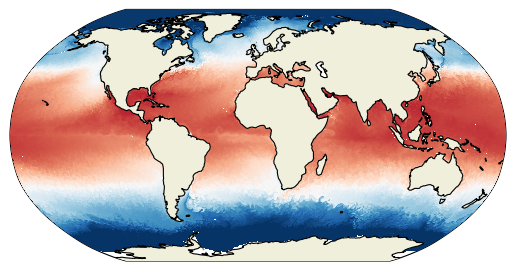

In [30]:
ecco.plot_proj_to_latlon_grid(grid.XC,
                              grid.YC,
                              ds_llc.Theta,
                              plot_type = 'pcolormesh',
                              dx=0.1,
                              dy=0.1,
                              projection_type = 'robin',
                              less_output = True)